making an stacking ensemble of the boosted tree models as estimators and Ridge as meta learner

In [1]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import catboost as cb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import pandas as pd 
import gc


In [2]:
print("Loading the Parquet masterpieces...")
train_df = pd.read_parquet("../data/model_ready/train_final.parquet")
valid_df = pd.read_parquet("../data/model_ready/valid_final.parquet")
test_df = pd.read_parquet("../data/model_ready/test_final.parquet")

# 1. Split into Features (X) and Target (y)
print("Splitting X and y...")
target_col = 'SalaryNormalized'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_valid = valid_df.drop(columns=[target_col])
y_valid = valid_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

#the values vary very much.. so log trainsforming them using log(1+ylabel) 
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)
y_test_log = np.log1p(y_test)

Loading the Parquet masterpieces...
Splitting X and y...


In [3]:
# Arrays to hold the Level-1 predictions
valid_preds = {}
test_preds = {}

In [4]:
# 2. The God-Tier XGBoost Setup (GPU Accelerated)
print("Firing up the GPU for XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=3000,        # Bumped it up
    learning_rate=0.03,       # Lowered it so it learns more carefully
    max_depth=7,              # Slightly deeper trees
    tree_method='hist',
    device='cuda',            # Keep your RTX 4050 sweating
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=100
)


# 3. Train the Beast
print("Training... Don't touch your laptop.")
xgb_model.fit(
    X_train, y_train_log,
    eval_set=[(X_train, y_train_log), (X_valid, y_valid_log)],    
    verbose=20               # Prints an update every 20 trees
)

valid_preds['xgb'] = xgb_model.predict(X_valid)
test_preds['xgb'] = xgb_model.predict(X_test)
del xgb_model
gc.collect() # Force Python to clear the VRAM

Firing up the GPU for XGBoost...
Training... Don't touch your laptop.
[0]	validation_0-rmse:0.48061	validation_1-rmse:0.35470
[20]	validation_0-rmse:0.33190	validation_1-rmse:0.23195
[40]	validation_0-rmse:0.26630	validation_1-rmse:0.20712
[60]	validation_0-rmse:0.23995	validation_1-rmse:0.21330
[80]	validation_0-rmse:0.22907	validation_1-rmse:0.22325
[100]	validation_0-rmse:0.22382	validation_1-rmse:0.23043
[120]	validation_0-rmse:0.22058	validation_1-rmse:0.23511
[140]	validation_0-rmse:0.21828	validation_1-rmse:0.23788
[141]	validation_0-rmse:0.21817	validation_1-rmse:0.23797


c:\Users\nishk\anaconda3\envs\torch_gpu\Lib\site-packages\xgboost\core.py:774: UserWarning: [10:59:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


39

In [5]:
# CatBoost eats tabular data for breakfast
cat_model = cb.CatBoostRegressor(
    iterations=3000,           # Number of trees
    learning_rate=0.03,        # Slow and steady
    depth=7,                   # Tree depth
    task_type='GPU',           # Force it onto the RTX 4050
    devices='0',               # Use your primary GPU
    od_type='Iter',            # Overfitting detector
    od_wait=200,               # Early stopping (waits 100 rounds)
    random_seed=42,
    verbose=2               # Print updates every 200 trees
)

print("Training CatBoost...")
cat_model.fit(
    X_train, y_train_log,
    eval_set=(X_valid, y_valid_log),
    use_best_model=True
)

valid_preds['cat'] = cat_model.predict(X_valid)
test_preds['cat'] = cat_model.predict(X_test)

del cat_model
gc.collect()

Training CatBoost...
0:	learn: 0.4813980	test: 0.3553831	best: 0.3553831 (0)	total: 258ms	remaining: 12m 53s
2:	learn: 0.4622881	test: 0.3377069	best: 0.3377069 (2)	total: 545ms	remaining: 9m 4s
4:	learn: 0.4444789	test: 0.3216618	best: 0.3216618 (4)	total: 693ms	remaining: 6m 54s
6:	learn: 0.4279090	test: 0.3068770	best: 0.3068770 (6)	total: 806ms	remaining: 5m 44s
8:	learn: 0.4126569	test: 0.2935994	best: 0.2935994 (8)	total: 904ms	remaining: 5m
10:	learn: 0.3984600	test: 0.2815593	best: 0.2815593 (10)	total: 995ms	remaining: 4m 30s
12:	learn: 0.3852995	test: 0.2706392	best: 0.2706392 (12)	total: 1.09s	remaining: 4m 10s
14:	learn: 0.3731649	test: 0.2609715	best: 0.2609715 (14)	total: 1.18s	remaining: 3m 54s
16:	learn: 0.3619228	test: 0.2523044	best: 0.2523044 (16)	total: 1.26s	remaining: 3m 40s
18:	learn: 0.3516012	test: 0.2447645	best: 0.2447645 (18)	total: 1.34s	remaining: 3m 30s
20:	learn: 0.3420526	test: 0.2381500	best: 0.2381500 (20)	total: 1.42s	remaining: 3m 21s
22:	learn: 0.3

0

In [6]:
print("Summoning the Microsoft Speed Demon...")

# The God-Tier LGBM Config
lgb_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=64,             # LGBM is leaf-wise, so we restrict this to stop it from overfitting
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    device='gpu',              # Keep the RTX 4050 sweating
    random_state=42,
    verbose=-1                 # Shuts up the annoying C++ warnings
)

print("Training LightGBM... blink and you might miss it.")
lgb_model.fit(
    X_train, y_train_log,
    eval_set=[(X_valid, y_valid_log)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(period=200)
    ]
)
valid_preds['lgb'] = lgb_model.predict(X_valid)
test_preds['lgb'] = lgb_model.predict(X_test)

del lgb_model
gc.collect()

Summoning the Microsoft Speed Demon...
Training LightGBM... blink and you might miss it.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[41]	valid_0's l2: 0.0430275


323

In [7]:
# ==========================================
# 4. THE META-LEARNER (RIDGE)
# ==========================================
print("\n🧠 Training the Meta-Learner...")

# Stack the predictions side-by-side into matrices
X_meta_train = np.column_stack((valid_preds['xgb'], valid_preds['cat'], valid_preds['lgb']))
X_meta_test = np.column_stack((test_preds['xgb'], test_preds['cat'], test_preds['lgb']))

meta_learner = Ridge(alpha=10.0, random_state=42)
meta_learner.fit(X_meta_train, y_valid_log)

print("\nUnleashing the Final Stack...")
final_preds_log = meta_learner.predict(X_meta_test)

# Reverse the log cheat code
final_preds_real = np.expm1(final_preds_log)


🧠 Training the Meta-Learner...

Unleashing the Final Stack...


In [8]:
# Flex the Metrics
final_mae = mean_absolute_error(y_test, final_preds_real)
final_r2 = r2_score(y_test, final_preds_real)
rmse = np.sqrt(mean_squared_error(y_test, final_preds_real))
print("\n" + "="*30)
print("  STACKING RESULTS  ")
print("="*30)
print(f"Final R2 Score: {final_r2:.4f}")
print(f"Final MAE:      £{final_mae:.2f}")
print(f"RMSE:           £{rmse:.2f}")
print("="*30 + "\n")


  STACKING RESULTS  
Final R2 Score: 0.6695
Final MAE:      £5112.27
RMSE:           £6938.58



Painting the Exodia Masterpiece...


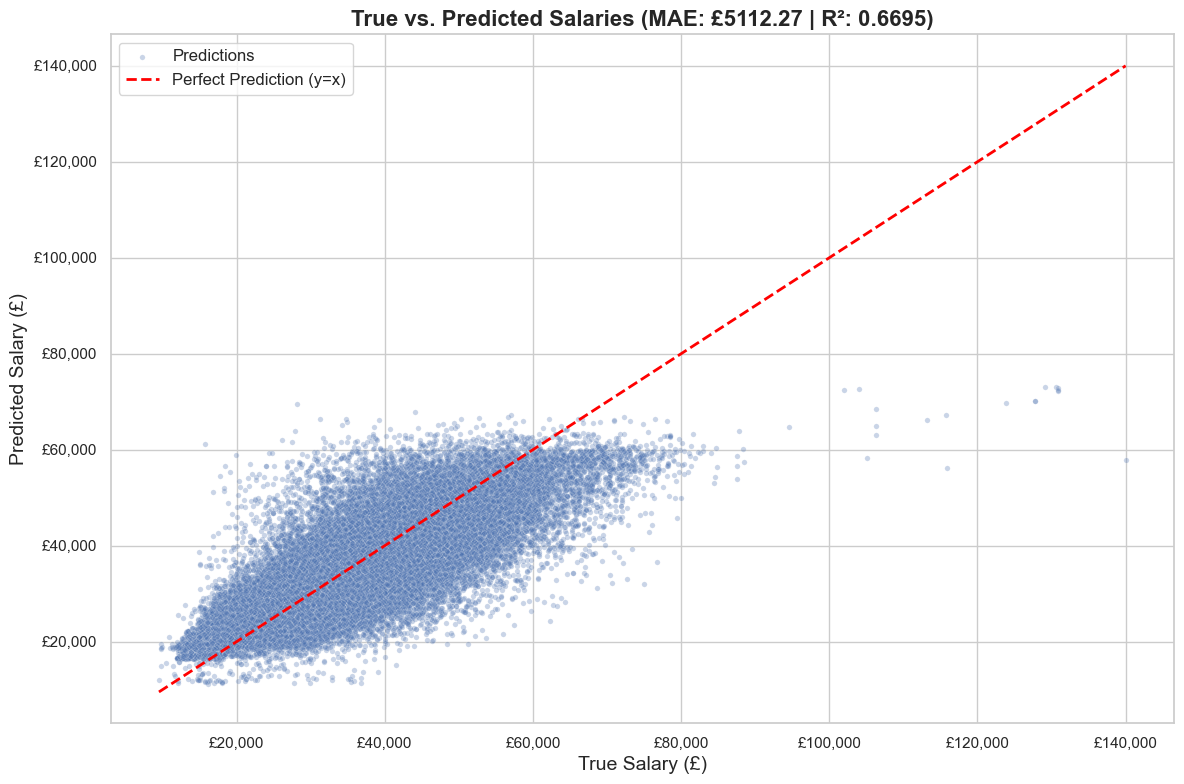

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Painting the Exodia Masterpiece...")

# Set the style to look professional (no boomer default charts here)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 1. The Scatter Plot
# alpha=0.3 makes the dots see-through so you can see where the data is dense
sns.scatterplot(
    x=y_test, 
    y=final_preds_real, 
    alpha=0.3, 
    color="#4C72B0", 
    s=15, # dot size
    label="Predictions"
)

# 2. The Line of Perfect Prediction (y = x)
# If a dot lands on this red dashed line, your model guessed the exact right penny.
min_val = min(y_test.min(), final_preds_real.min())
max_val = max(y_test.max(), final_preds_real.max())

plt.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color='red', 
    linestyle='--', 
    linewidth=2,
    label="Perfect Prediction (y=x)"
)

# 3. Flex the labels and title
plt.title(f"True vs. Predicted Salaries (MAE: £{final_mae:.2f} | R²: {final_r2:.4f})", fontsize=16, fontweight='bold')
plt.xlabel("True Salary (£)", fontsize=14)
plt.ylabel("Predicted Salary (£)", fontsize=14)

# Format the axes to show "£" (because we are fancy like that)
import matplotlib.ticker as ticker
formatter = ticker.StrMethodFormatter('£{x:,.0f}')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend(fontsize=12)
plt.tight_layout()

# Render the absolute cinema
plt.show()